In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

In [3]:
orders = pd.read_csv('../data/olist_orders_dataset.csv')

In [5]:
orders = pd.DataFrame(orders)
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [19]:
status_counts = orders['order_status'].value_counts()
convertion = (status_counts).apply(lambda x: (x/status_counts.sum())*100)
print(convertion)

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: count, dtype: float64


97% доставляемость это сильная сторона Olist. Это значит что операционно бизнес работает хорошо — заказы доходят.
Но retention 3% — это значит что люди не возвращаются после успешной доставки. скорее это продуктовая проблема, хотя мы не знаем есть ли другие маркетплейсы, которые доставляют быстрее, может заказ идет 2 месяца, когда на другом маркетплкейсе доходит за 2 дня, но тк он уже оплачени то люди ждут

In [14]:
mean_times = (pd.to_datetime(orders['order_delivered_customer_date']) - pd.to_datetime(orders['order_purchase_timestamp'])).dt.days
print(mean_times.mean())

12.094085575687217


Text(0.5, 1.0, 'Funnel analysis(kinda)')

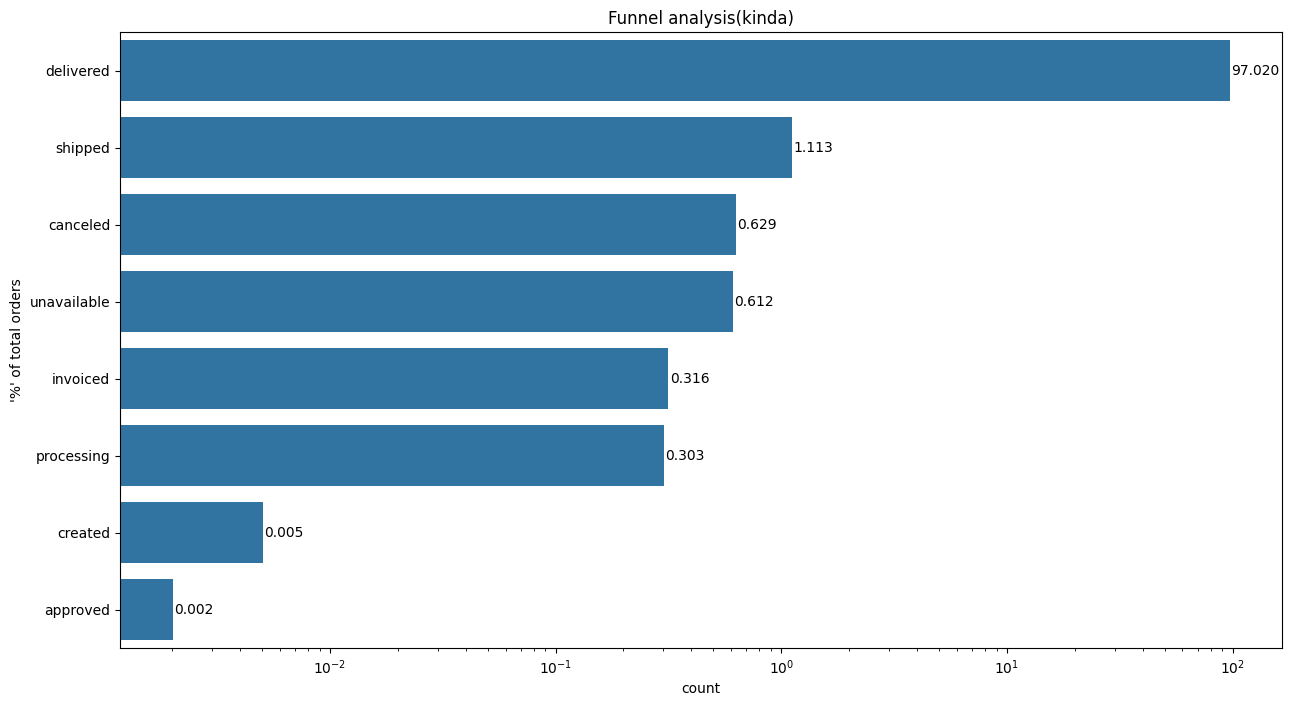

In [33]:
convertion = pd.DataFrame(convertion)

plt.figure(figsize=(15, 8))

stat = sns.barplot(x="count", y="order_status", data=convertion)
stat.bar_label(stat.containers[0], fmt='%.3f', padding=1)

plt.xticks(rotation=0)
plt.xscale('log')
plt.ylabel("'%' of total orders")
plt.title('Funnel analysis(kinda)')

In [38]:
hypothesis_1 = orders.loc[orders['order_status'].isin(['shipped','invoiced','processing'])]
hypothesis_1.head()

hyp_1_mean_times = (pd.to_datetime(max(orders['order_purchase_timestamp'])) - pd.to_datetime(hypothesis_1['order_purchase_timestamp'])).dt.days
print(hyp_1_mean_times.mean())

339.7224157955865


1.8% заказов застряли в обработке
Среднее время с момента создания — 339 дней
Вывод: это не "в процессе", это потерянные заказы

и тут нужно ограничение датасета
